# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis

In [3]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})

# Load the Datasets

In [4]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

# Define the Training and Target Cols 

In [5]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

# DataFrames + Splitting + Scaling

In [6]:
# Creo i dataframe : 
#   1. All
#   2. Bilanciato

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

df_bal = data.make_balanced_df(df_all, seed=0)

print("df_all:", df_all.shape)
print("df_bal:", df_bal.shape)
print("Counts df_all:", df_all["class"].value_counts().to_dict())
print("Counts df_bal:", df_bal["class"].value_counts().to_dict())

df_all: (337351, 76)
df_bal: (163894, 76)
Counts df_all: {1: 255404, 0: 81947}
Counts df_bal: {1: 81947, 0: 81947}


In [7]:
# Splitting :
df_train_all, df_val_all, df_test_all = data.split_df_once(df_all, seed=0)

print("SPLITS df_all:")
print("train:", df_train_all.shape, df_train_all["class"].value_counts().to_dict())
print("val  :", df_val_all.shape,   df_val_all["class"].value_counts().to_dict())
print("test :", df_test_all.shape,  df_test_all["class"].value_counts().to_dict())

df_train_bal, df_val_bal, df_test_bal = data.split_df_once(df_bal, seed=0)

print("SPLITS df_bal:")
print("train:", df_train_bal.shape, df_train_bal["class"].value_counts().to_dict())
print("val  :", df_val_bal.shape,   df_val_bal["class"].value_counts().to_dict())
print("test :", df_test_bal.shape,  df_test_bal["class"].value_counts().to_dict())

SPLITS df_all:
train: (269880, 76) {1: 204276, 0: 65604}
val  : (33735, 76) {1: 25636, 0: 8099}
test : (33736, 76) {1: 25492, 0: 8244}
SPLITS df_bal:
train: (131115, 76) {1: 65596, 0: 65519}
val  : (16389, 76) {0: 8228, 1: 8161}
test : (16390, 76) {0: 8200, 1: 8190}


In [11]:
# Scaling :
SCALING_MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_LOCAL",
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

OUTDIR = "../results/prepared_splits"   # relativo a notebooks/
os.makedirs(OUTDIR, exist_ok=True)

RUN_TAG = "pat100"
RUN_SUFFIX = f"_{RUN_TAG}"

In [9]:
def apply_and_save_all_scalings(
    df_train, df_val, df_test,
    dataset_tag: str,             # "unbalanced" o "balanced"
    train_cols, y_cols,
    outdir: str,
):
    base = os.path.join(outdir, dataset_tag)
    os.makedirs(base, exist_ok=True)

    saved_paths = {}

    for mode in SCALING_MODES:
        df_tr_s, df_va_s, df_te_s, scalers = data.prepare_splits_with_scaling(
            df_train, df_val, df_test,
            train_cols=train_cols,
            y_cols=y_cols,
            mode=mode,
            class_col="class",
        )

        mode_dir = os.path.join(base, mode)
        os.makedirs(mode_dir, exist_ok=True)

        # DataFrames scalati
        df_tr_s.to_pickle(os.path.join(mode_dir, "train.pkl"))
        df_va_s.to_pickle(os.path.join(mode_dir, "val.pkl"))
        df_te_s.to_pickle(os.path.join(mode_dir, "test.pkl"))

        # Scalers
        joblib.dump(scalers, os.path.join(mode_dir, "scalers.joblib"))

        saved_paths[mode] = mode_dir
        print(f"[{dataset_tag}] saved {mode} -> {mode_dir}")

    return saved_paths

In [10]:
# Non lo ri-runno, li ho già
paths_unbalanced = apply_and_save_all_scalings(
    df_train_all, df_val_all, df_test_all,
    dataset_tag="unbalanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

paths_balanced = apply_and_save_all_scalings(
    df_train_bal, df_val_bal, df_test_bal,
    dataset_tag="balanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

[unbalanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/unbalanced/X_NONE__Y_NONE
[unbalanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_LOCAL
[unbalanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_GLOBAL
[unbalanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_LOCAL__Y_LOCAL
[unbalanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_NONE__Y_LOCAL
[balanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/balanced/X_NONE__Y_NONE
[balanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_LOCAL
[balanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_GLOBAL
[balanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_LOCAL__Y_LOCAL
[balanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/balanced/X_NONE__Y_LOCAL


# Trainings 

In [12]:
def load_prepared(mode_dir: str):
    df_tr = pd.read_pickle(os.path.join(mode_dir, "train.pkl"))
    df_va = pd.read_pickle(os.path.join(mode_dir, "val.pkl"))
    df_te = pd.read_pickle(os.path.join(mode_dir, "test.pkl"))
    scalers = joblib.load(os.path.join(mode_dir, "scalers.joblib"))
    return df_tr, df_va, df_te, scalers

In [13]:
results_balanced_huber = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} (HUBER) ({RUN_TAG})")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",     # new
        huber_delta=1.0,       
    )

    results_balanced_huber[mode] = res


TRAIN BALANCED — X_NONE__Y_NONE (HUBER) (pat100)
[ep    1] train=0.914419  val=0.525311  best=0.525311  bad=0/100
[ep   10] train=0.451702  val=0.444158  best=0.444158  bad=0/100
[ep   20] train=0.438102  val=0.483072  best=0.409351  bad=5/100
[ep   30] train=0.383746  val=0.456812  best=0.391817  bad=8/100
[ep   40] train=0.358502  val=0.519858  best=0.320985  bad=5/100
[ep   50] train=0.299445  val=0.291171  best=0.291171  bad=0/100
[ep   60] train=0.277919  val=0.304265  best=0.275674  bad=7/100
[ep   70] train=0.273463  val=0.407070  best=0.247917  bad=7/100
[ep   80] train=0.257115  val=0.281500  best=0.243987  bad=5/100
[ep   90] train=0.282660  val=0.361658  best=0.238082  bad=9/100
[ep  100] train=0.260494  val=0.315586  best=0.218469  bad=3/100
[ep  110] train=0.239287  val=0.261159  best=0.218469  bad=13/100
[ep  120] train=0.237426  val=0.343104  best=0.214330  bad=1/100
[ep  130] train=0.239281  val=0.311815  best=0.214330  bad=11/100
[ep  140] train=0.238603  val=0.454894

In [ ]:
results_unbalanced_huber = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode} (HUBER) ({RUN_TAG})")
    print("="*90)

    res= training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",     # new
        huber_delta=1.0,       
    )

    results_unbalanced_huber[mode] = res


TRAIN UNBALANCED — X_NONE__Y_NONE (HUBER) (pat100)
[ep    1] train=0.785861  val=0.466286  best=0.466286  bad=0/100
[ep   10] train=0.433084  val=0.417321  best=0.417321  bad=0/100
[ep   20] train=0.353423  val=0.366007  best=0.347385  bad=2/100
[ep   30] train=0.285763  val=0.283617  best=0.273159  bad=1/100
[ep   40] train=0.279037  val=0.261653  best=0.261653  bad=0/100
[ep   50] train=0.263583  val=0.252531  best=0.252531  bad=0/100
[ep   60] train=0.250227  val=0.233548  best=0.233548  bad=0/100
[ep   70] train=0.239230  val=0.282599  best=0.233548  bad=10/100
[ep   80] train=0.570675  val=0.435068  best=0.226094  bad=5/100
[ep   90] train=0.242649  val=0.243838  best=0.226094  bad=15/100
[ep  100] train=0.231871  val=0.226734  best=0.222243  bad=1/100
[ep  110] train=0.228910  val=0.224767  best=0.222243  bad=11/100
[ep  120] train=0.289776  val=0.282573  best=0.220008  bad=9/100
[ep  130] train=0.229910  val=0.222003  best=0.220008  bad=19/100
[ep  140] train=0.227389  val=0.22

In [ ]:
# Salvo i run HUBER
OUT_ROOT = "../results/runs_prepared"
dataset_tag = "balanced"
loss_tag = "HUBER_d1_pat100"  

for mode, res in results_balanced_huber.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/balanced/HUBER_d1_pat100/X_NONE__Y_NONE
saved -> ../results/runs_prepared/balanced/HUBER_d1_pat100/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/HUBER_d1_pat100/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/balanced/HUBER_d1_pat100/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/HUBER_d1_pat100/X_NONE__Y_LOCAL


In [ ]:
dataset_tag = "unbalanced"
loss_tag = "HUBER_d1_pat100"

for mode, res in results_unbalanced_huber.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/unbalanced/HUBER_d1_pat100/X_NONE__Y_NONE
saved -> ../results/runs_prepared/unbalanced/HUBER_d1_pat100/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/HUBER_d1_pat100/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/unbalanced/HUBER_d1_pat100/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/HUBER_d1_pat100/X_NONE__Y_LOCAL


# Predictions - Huber

In [44]:
# ============================================
# BALANCED — HUBER patience 100
# ============================================

preds_bal_huber_pat100 = {}

for mode in SCALING_MODES:
    res = results_balanced_huber[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,   # RAW test set
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_bal_huber_pat100[mode] = df_pred
    print(mode, "HUBER pat100 done", df_pred.shape)


# ============================================
# UNBALANCED — HUBER patience 100
# ============================================

preds_unbal_huber_pat100 = {}

for mode in SCALING_MODES:
    res = results_unbalanced_huber[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_unbal_huber_pat100[mode] = df_pred
    print(mode, "HUBER pat100 done", df_pred.shape)

X_NONE__Y_NONE HUBER pat100 done (16390, 2)
X_GLOBAL__Y_LOCAL HUBER pat100 done (16390, 2)
X_GLOBAL__Y_GLOBAL HUBER pat100 done (16390, 2)
X_LOCAL__Y_LOCAL HUBER pat100 done (16390, 2)
X_NONE__Y_LOCAL HUBER pat100 done (16390, 2)
X_NONE__Y_NONE HUBER pat100 done (33736, 2)
X_GLOBAL__Y_LOCAL HUBER pat100 done (33736, 2)
X_GLOBAL__Y_GLOBAL HUBER pat100 done (33736, 2)
X_LOCAL__Y_LOCAL HUBER pat100 done (33736, 2)
X_NONE__Y_LOCAL HUBER pat100 done (33736, 2)


# Plots

In [45]:
masses_bal_huber_pat100 = {}

for mode in SCALING_MODES:
    
    dfp = preds_bal_huber_pat100[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal_huber_pat100[mode] = m
    print(mode, "HUBER pat100 done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE HUBER pat100 done: 107.23995511085772 28.59315706824694
X_GLOBAL__Y_LOCAL HUBER pat100 done: 109.73785907124346 22.31922705306143
X_GLOBAL__Y_GLOBAL HUBER pat100 done: 109.29462520457717 22.928231144946402
X_LOCAL__Y_LOCAL HUBER pat100 done: 110.28035004039751 25.18450675229163
X_NONE__Y_LOCAL HUBER pat100 done: 109.87888978337773 28.786465498548374


In [46]:
masses_unbal_huber_pat100 = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal_huber_pat100[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal_huber_pat100[mode] = m
    print(mode, "HUBER pat100 done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE HUBER pat100 done: 118.7722818202587 21.3901390654489
X_GLOBAL__Y_LOCAL HUBER pat100 done: 117.08200730798399 16.703380051298616
X_GLOBAL__Y_GLOBAL HUBER pat100 done: 117.27699342255256 17.142701756717376
X_LOCAL__Y_LOCAL HUBER pat100 done: 117.58625516684405 17.566886449500384
X_NONE__Y_LOCAL HUBER pat100 done: 115.47333127121212 20.401247839712784


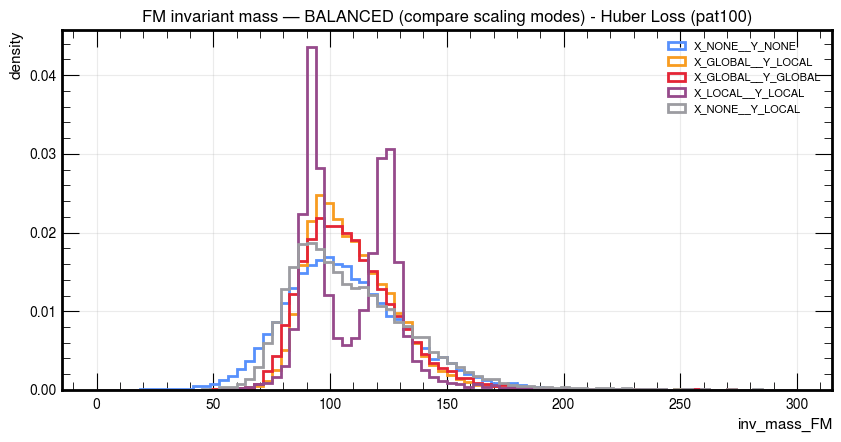

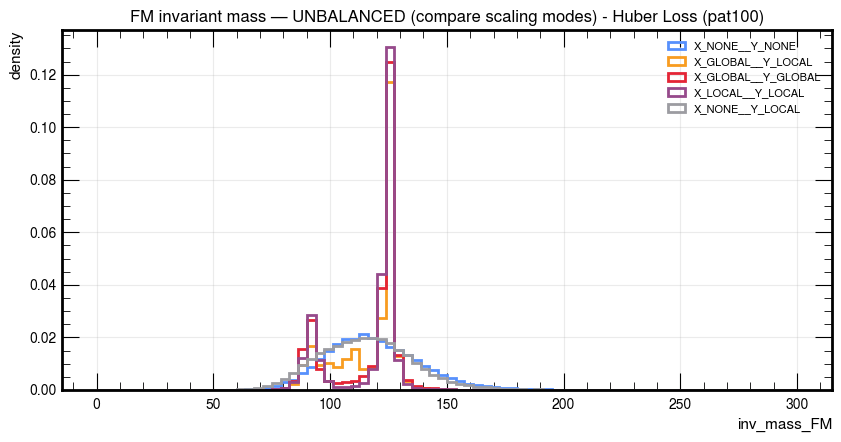

In [47]:
massesPlots.plot_mass_overlay(
    masses_bal_huber_pat100,
    title="FM invariant mass — BALANCED (compare scaling modes) - Huber Loss (pat100)",
    bins=80,
    range_=(0, 300), 
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_unbal_huber_pat100,
    title="FM invariant mass — UNBALANCED (compare scaling modes) - Huber Loss (pat100)",
    bins=80,
    range_=(0, 300),
    density=True,
)

In [48]:
# Per separare i plot :

m_dy_bal = (df_test_bal["class"].to_numpy() == 0)
m_h_bal  = (df_test_bal["class"].to_numpy() == 1)

m_dy_unb = (df_test_all["class"].to_numpy() == 0)
m_h_unb  = (df_test_all["class"].to_numpy() == 1)

# BALANCED
masses_bal_dy_huber_pat100 = {
    mode: np.asarray(masses_bal_huber_pat100[mode])[m_dy_bal]
    for mode in SCALING_MODES
}

masses_bal_h_huber_pat100 = {
    mode: np.asarray(masses_bal_huber_pat100[mode])[m_h_bal]
    for mode in SCALING_MODES
}

# UNBALANCED
masses_unb_dy_huber_pat100 = {
    mode: np.asarray(masses_unbal_huber_pat100[mode])[m_dy_unb]
    for mode in SCALING_MODES
}

masses_unb_h_huber_pat100 = {
    mode: np.asarray(masses_unbal_huber_pat100[mode])[m_h_unb]
    for mode in SCALING_MODES
}

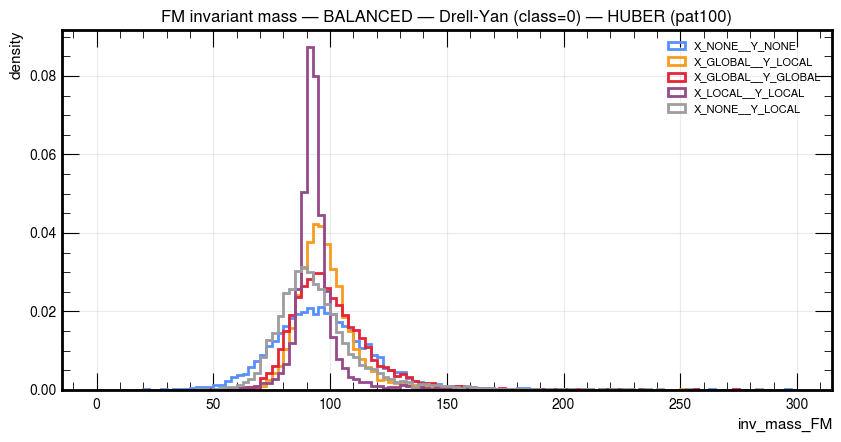

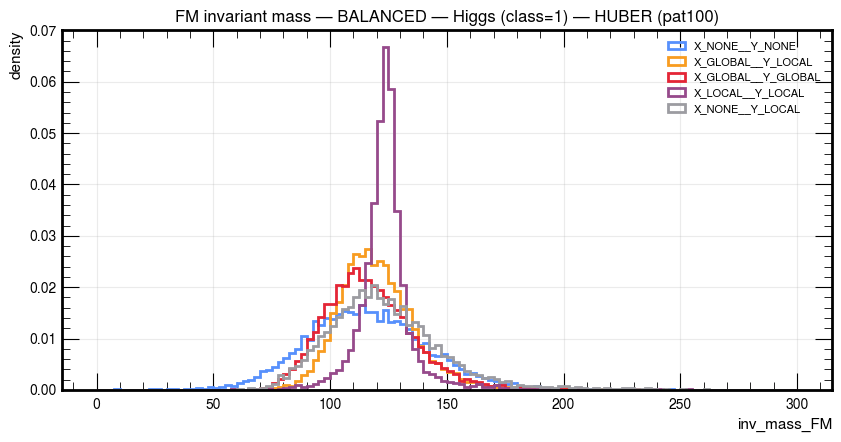

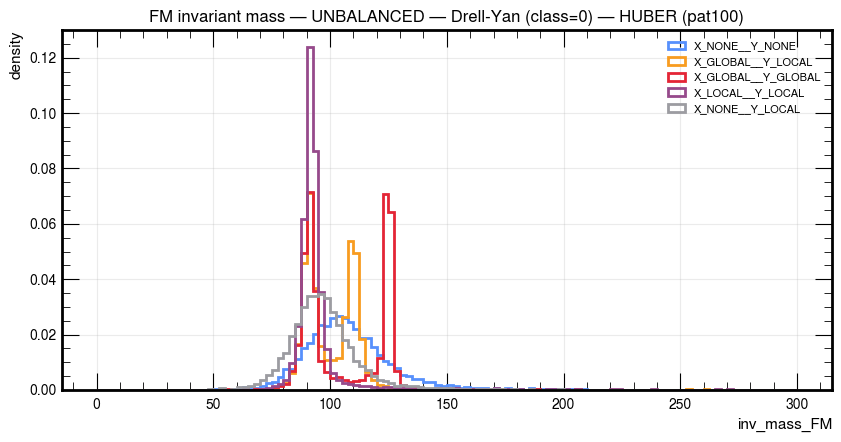

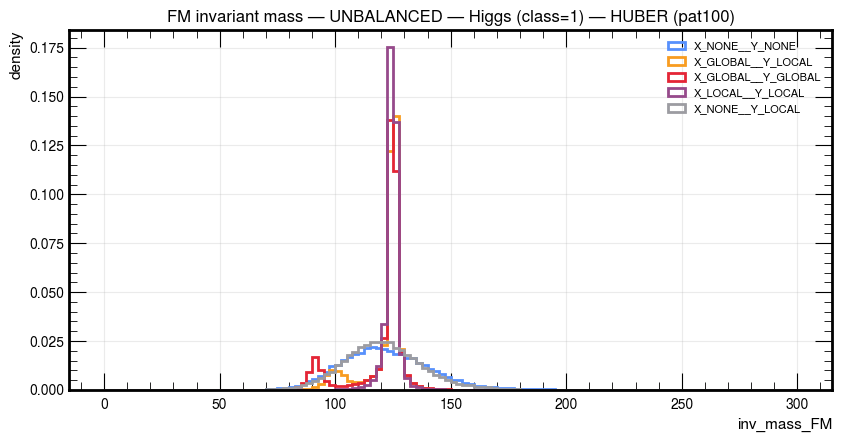

In [49]:
common_range = (0, 300)

# BALANCED — HUBER pat100
massesPlots.plot_mass_overlay(
    masses_bal_dy_huber_pat100,
    title="FM invariant mass — BALANCED — Drell-Yan (class=0) — HUBER (pat100)",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_bal_h_huber_pat100,
    title="FM invariant mass — BALANCED — Higgs (class=1) — HUBER (pat100)",
    bins=120,
    range_=common_range,
    density=True,
)

# UNBALANCED — HUBER pat100
massesPlots.plot_mass_overlay(
    masses_unb_dy_huber_pat100,
    title="FM invariant mass — UNBALANCED — Drell-Yan (class=0) — HUBER (pat100)",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_unb_h_huber_pat100,
    title="FM invariant mass — UNBALANCED — Higgs (class=1) — HUBER (pat100)",
    bins=120,
    range_=common_range,
    density=True,
)

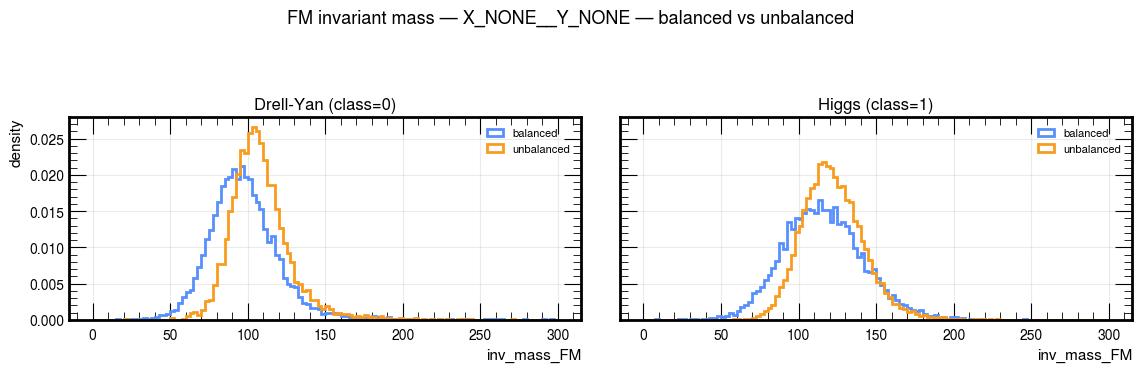

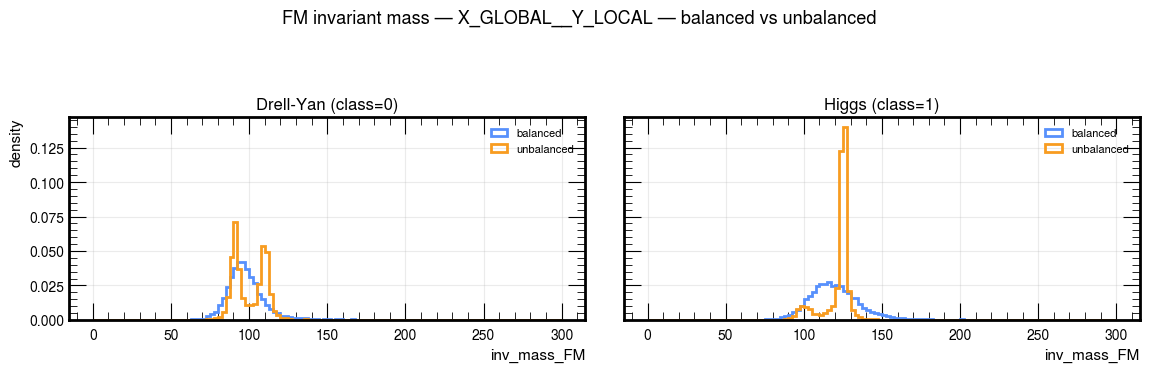

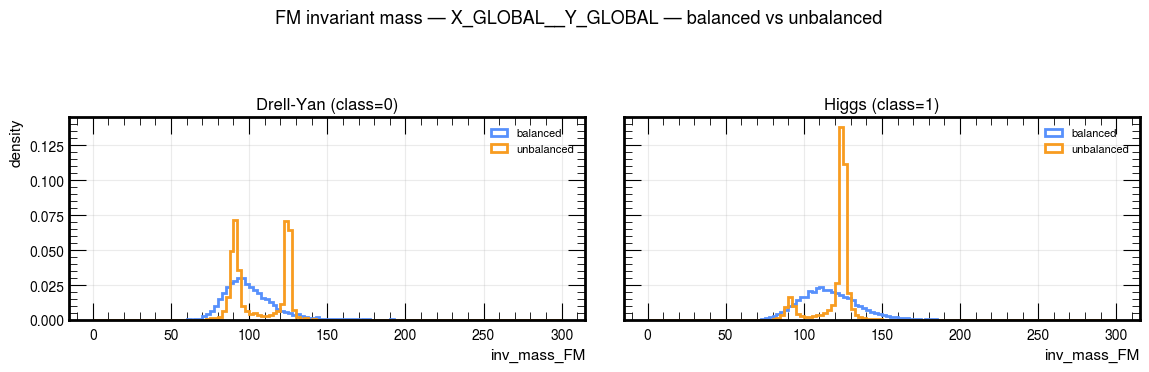

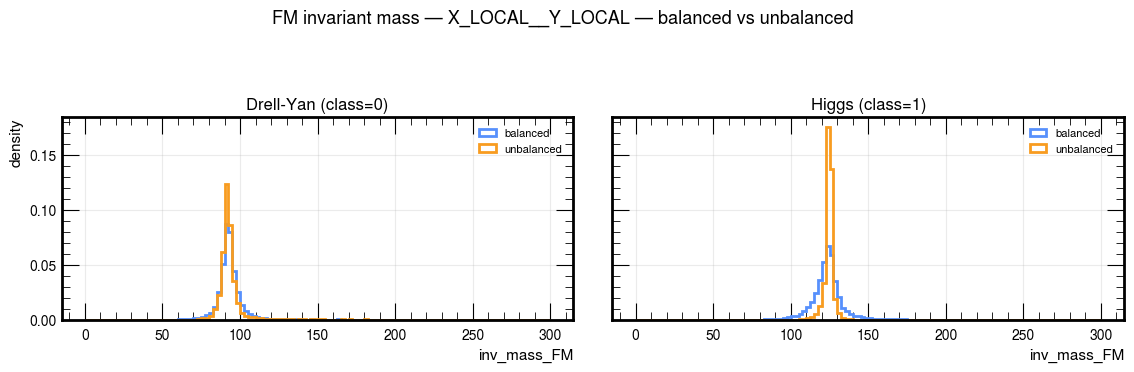

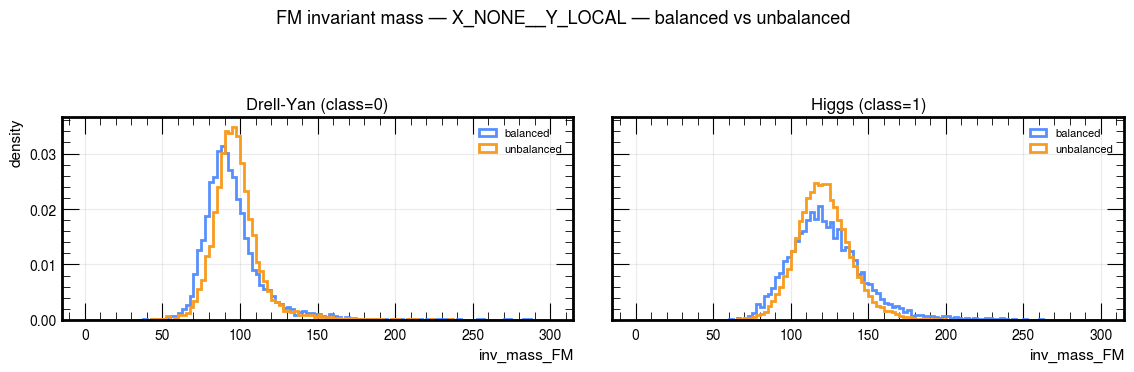

In [50]:
massesPlots.plot_balanced_vs_unbalanced_by_mode(
    masses_bal=masses_bal_huber_pat100,
    masses_unbal=masses_unbal_huber_pat100,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    bins=120,
    range_=(0, 300), 
    density=True,
)

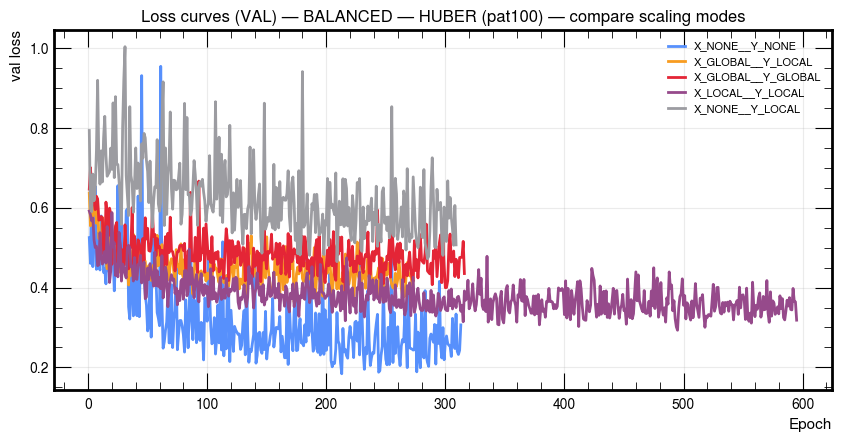

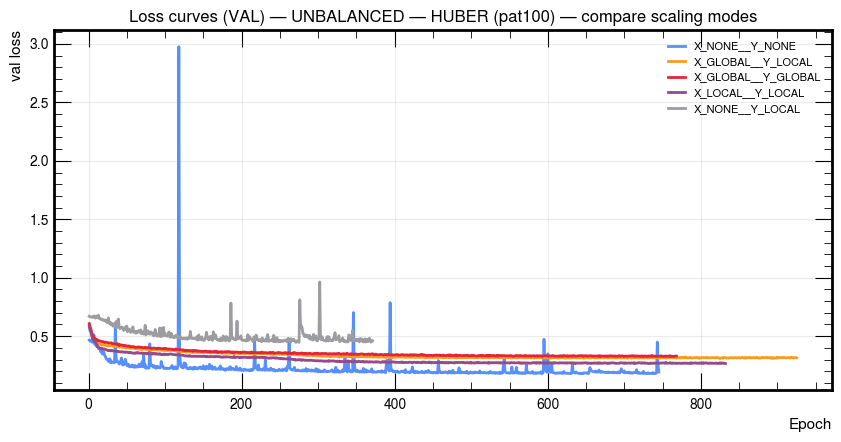

In [51]:
lossPlots.plot_loss_overlay(
    results_balanced_huber,
    title="Loss curves (VAL) — BALANCED — HUBER (pat100) — compare scaling modes",
    which="val",
    logy=False,
)

lossPlots.plot_loss_overlay(
    results_unbalanced_huber,
    title="Loss curves (VAL) — UNBALANCED — HUBER (pat100) — compare scaling modes",
    which="val",
)

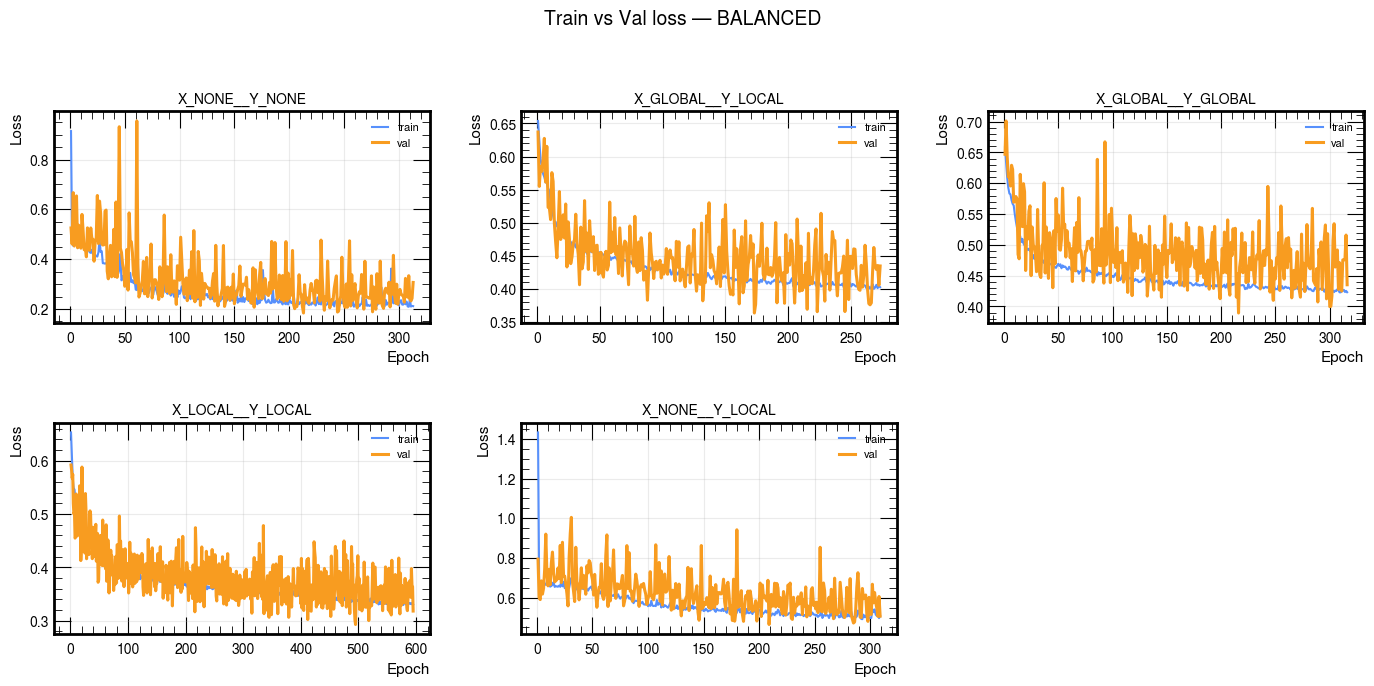

In [52]:
lossPlots.plot_loss_grid(
    results_balanced_huber,
    title="Train vs Val loss — BALANCED",
    order=SCALING_MODES,
    ncols=3,
)

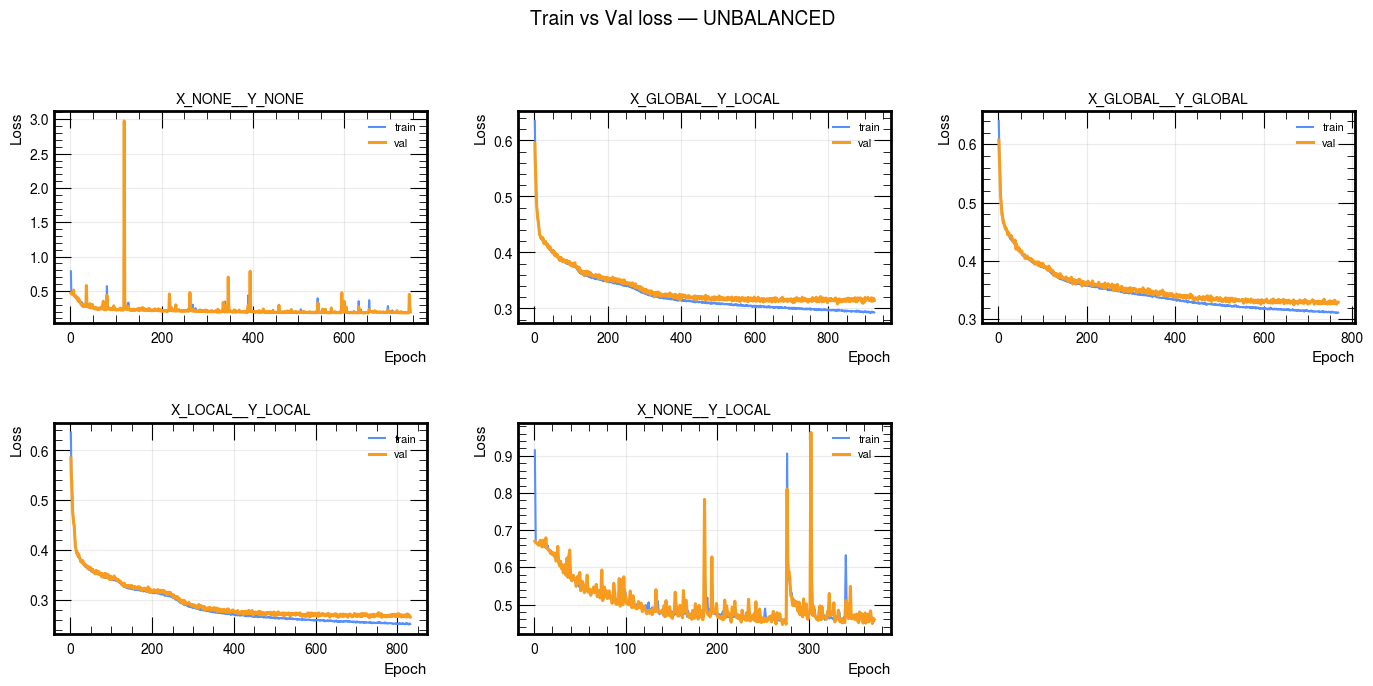

In [53]:
lossPlots.plot_loss_grid(
    results_unbalanced_huber,
    title="Train vs Val loss — UNBALANCED",
    order=SCALING_MODES,
    ncols=3,
)

# Analysis
- S/B within the window (110-130) GeV

In [55]:
print("S/B:")

tab_long, tab_pivot = analysis.compute_S_over_B_all_modes(
    masses_bal=masses_bal_huber_pat100,
    masses_unbal=masses_unbal_huber_pat100,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    window=(110,130),
    save_csv=True,
)

tab_pivot

S/B:


,mode,balanced,unbalanced
0,X_GLOBAL__Y_GLOBAL,2.322230,5.818105
1,X_GLOBAL__Y_LOCAL,5.083333,12.555293
2,X_LOCAL__Y_LOCAL,27.215859,137.284916
3,X_NONE__Y_LOCAL,3.766367,13.458904
4,X_NONE__Y_NONE,1.739319,4.311710


# Comparison MSE vs Huber Loss

In [56]:
# Carico le run :
results_balanced_mse_pat100 = {}

OUT_ROOT = "../results/runs_prepared"
dataset_tag = "balanced"

for mode in SCALING_MODES:
    save_dir = os.path.join(OUT_ROOT, dataset_tag, f"{mode}_pat100")
    res = training.load_run(save_dir)
    results_balanced_mse_pat100[mode] = res
    print("Loaded MSE pat100:", mode)

results_balanced_huber_pat100 = {}

loss_tag = "HUBER_d1_pat100"

for mode in SCALING_MODES:
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    res = training.load_run(save_dir)
    results_balanced_huber_pat100[mode] = res
    print("Loaded HUBER pat100:", mode)

Loaded MSE pat100: X_NONE__Y_NONE
Loaded MSE pat100: X_GLOBAL__Y_LOCAL
Loaded MSE pat100: X_GLOBAL__Y_GLOBAL
Loaded MSE pat100: X_LOCAL__Y_LOCAL
Loaded MSE pat100: X_NONE__Y_LOCAL
Loaded HUBER pat100: X_NONE__Y_NONE
Loaded HUBER pat100: X_GLOBAL__Y_LOCAL
Loaded HUBER pat100: X_GLOBAL__Y_GLOBAL
Loaded HUBER pat100: X_LOCAL__Y_LOCAL
Loaded HUBER pat100: X_NONE__Y_LOCAL


In [57]:
# Carico le run UNBALANCED
results_unbalanced_mse_pat100 = {}

OUT_ROOT = "../results/runs_prepared"
dataset_tag = "unbalanced"

for mode in SCALING_MODES:
    save_dir = os.path.join(OUT_ROOT, dataset_tag, f"{mode}_pat100")
    res = training.load_run(save_dir)
    results_unbalanced_mse_pat100[mode] = res
    print("Loaded MSE pat100:", mode)

results_unbalanced_huber_pat100 = {}

loss_tag = "HUBER_d1_pat100"

for mode in SCALING_MODES:
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    res = training.load_run(save_dir)
    results_unbalanced_huber_pat100[mode] = res
    print("Loaded HUBER pat100:", mode)

Loaded MSE pat100: X_NONE__Y_NONE
Loaded MSE pat100: X_GLOBAL__Y_LOCAL
Loaded MSE pat100: X_GLOBAL__Y_GLOBAL
Loaded MSE pat100: X_LOCAL__Y_LOCAL
Loaded MSE pat100: X_NONE__Y_LOCAL
Loaded HUBER pat100: X_NONE__Y_NONE
Loaded HUBER pat100: X_GLOBAL__Y_LOCAL
Loaded HUBER pat100: X_GLOBAL__Y_GLOBAL
Loaded HUBER pat100: X_LOCAL__Y_LOCAL
Loaded HUBER pat100: X_NONE__Y_LOCAL


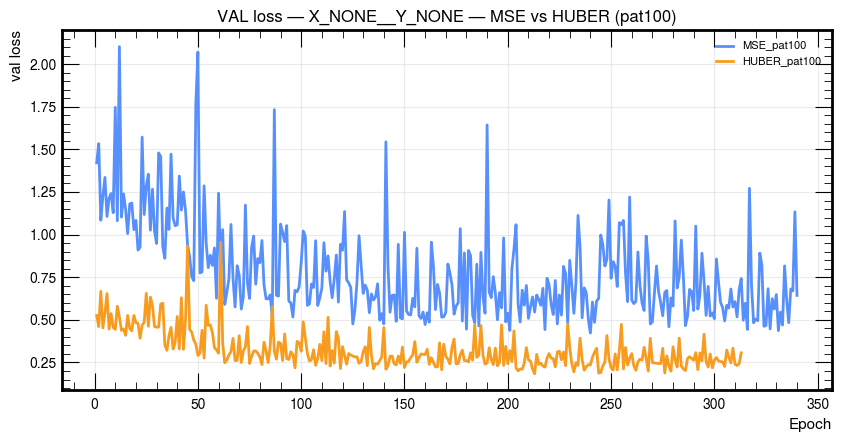

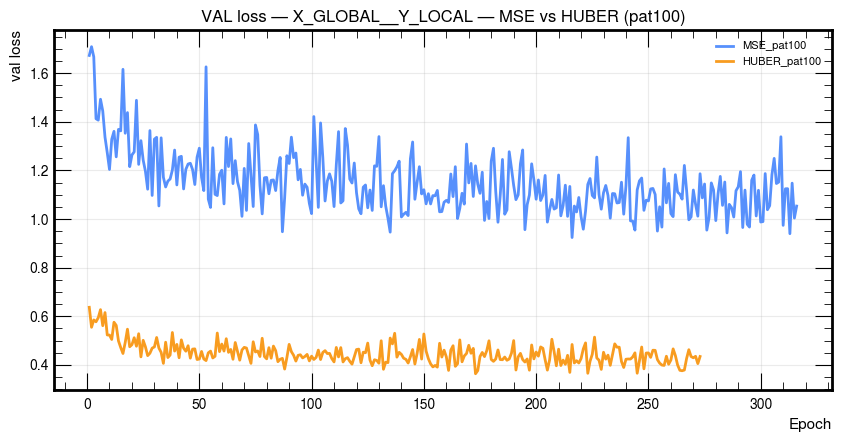

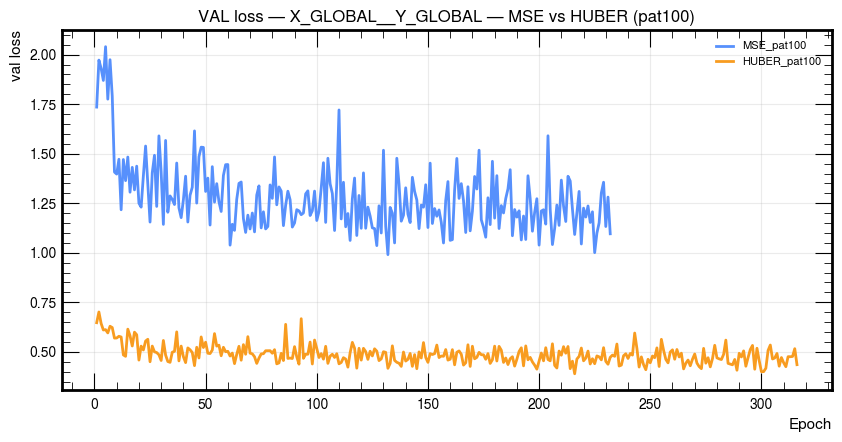

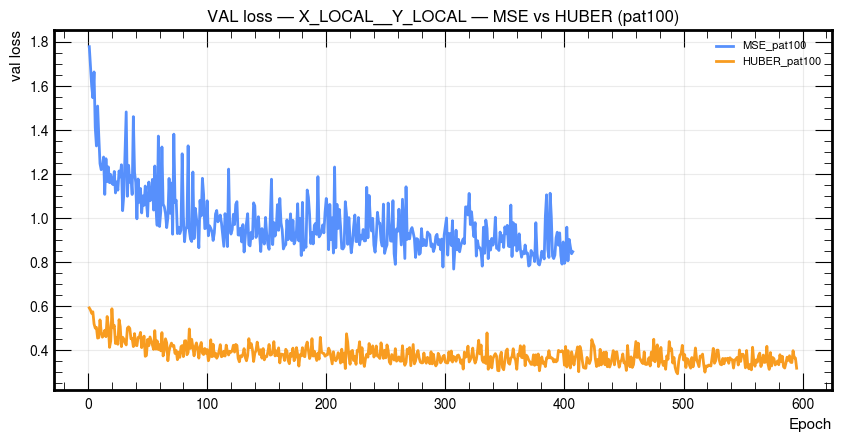

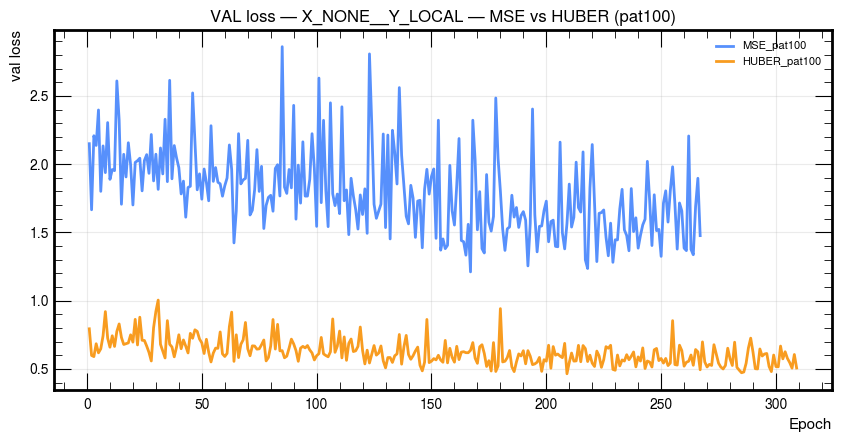

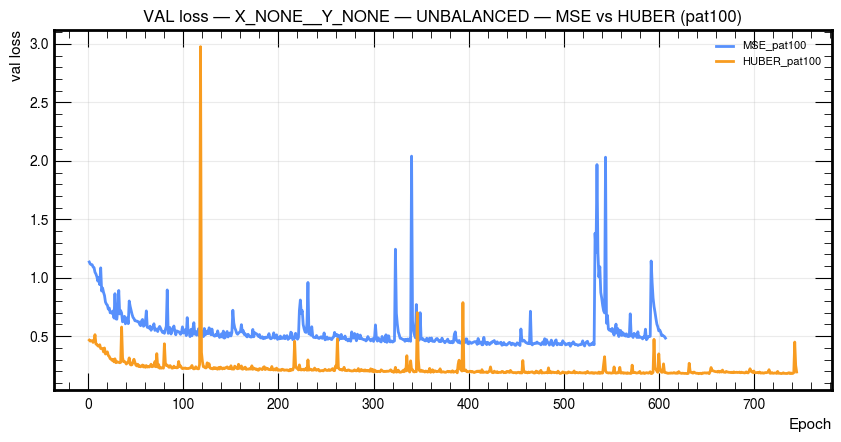

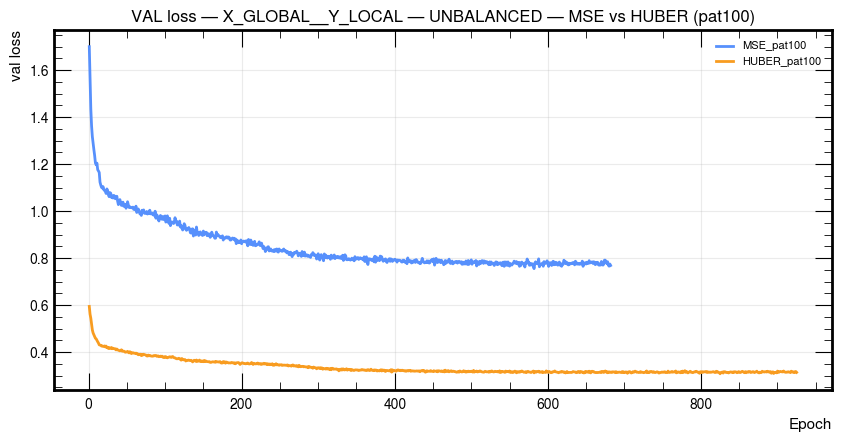

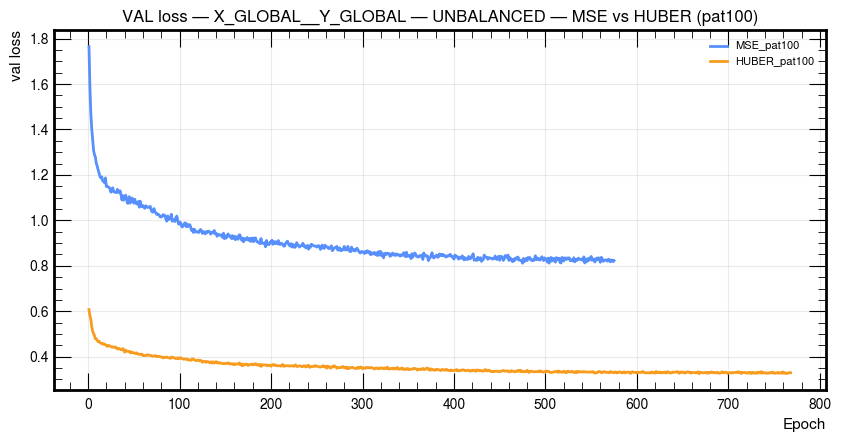

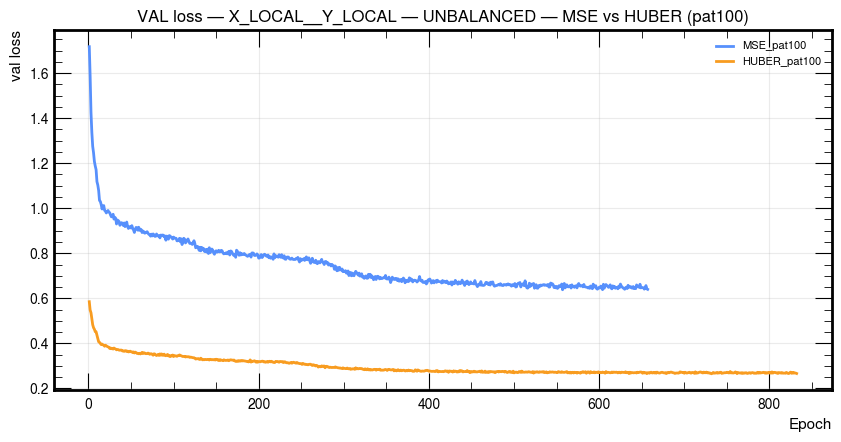

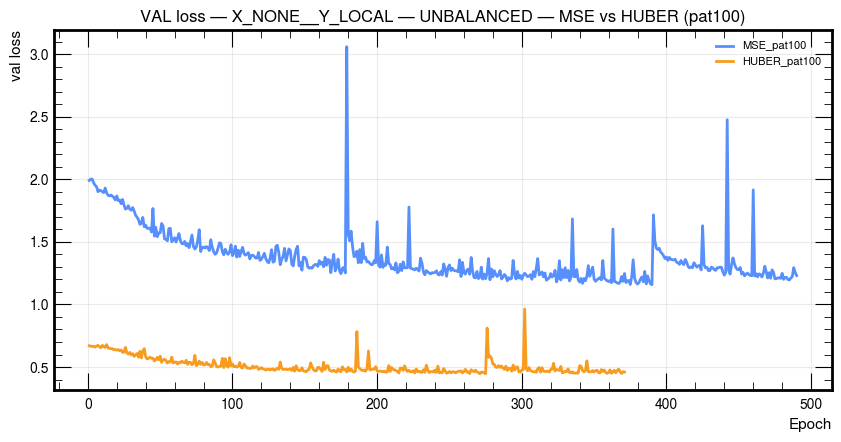

In [58]:
for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE_pat100": results_balanced_mse_pat100[mode],
            "HUBER_pat100": results_balanced_huber_pat100[mode],
        },
        title=f"VAL loss — {mode} — MSE vs HUBER (pat100)",
        which="val",
        logy=False,
    )

for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE_pat100": results_unbalanced_mse_pat100[mode],
            "HUBER_pat100": results_unbalanced_huber_pat100[mode],
        },
        title=f"VAL loss — {mode} — UNBALANCED — MSE vs HUBER (pat100)",
        which="val",
        logy=False,
    )

In [59]:
# carico le masse MSE
OUT = "../results/masses"

bal_dy_npz = np.load(os.path.join(OUT, f"masses_bal_nonflat_mse_dy{RUN_SUFFIX}.npz"))
bal_h_npz  = np.load(os.path.join(OUT, f"masses_bal_nonflat_mse_h{RUN_SUFFIX}.npz"))

unbal_dy_npz = np.load(os.path.join(OUT, f"masses_unbal_nonflat_mse_dy{RUN_SUFFIX}.npz"))
unbal_h_npz  = np.load(os.path.join(OUT, f"masses_unbal_nonflat_mse_h{RUN_SUFFIX}.npz"))

masses_bal_dy_mse_pat100 = {mode: bal_dy_npz[mode] for mode in SCALING_MODES}
masses_bal_h_mse_pat100  = {mode: bal_h_npz[mode]  for mode in SCALING_MODES}

masses_unb_dy_mse_pat100 = {mode: unbal_dy_npz[mode] for mode in SCALING_MODES}
masses_unb_h_mse_pat100  = {mode: unbal_h_npz[mode]  for mode in SCALING_MODES}

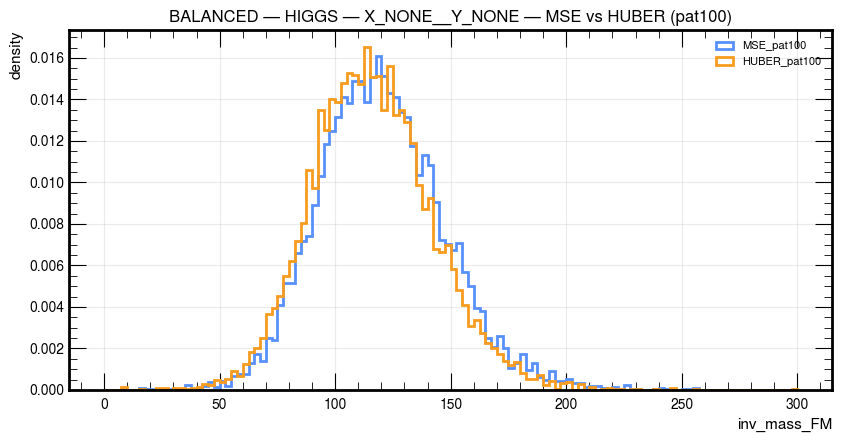

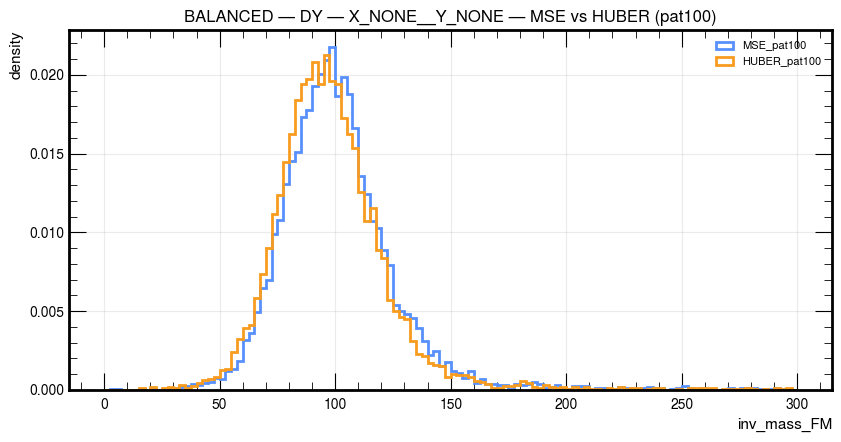

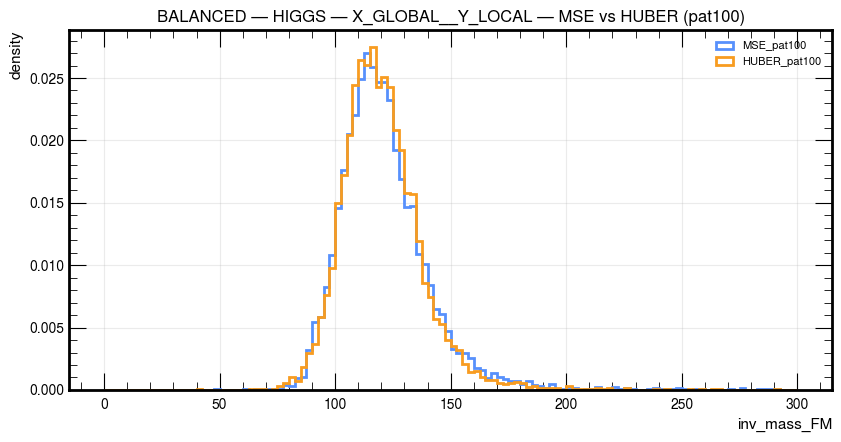

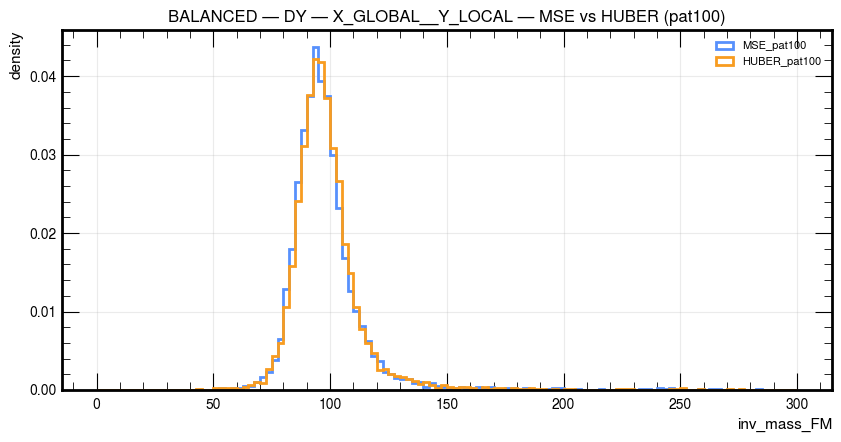

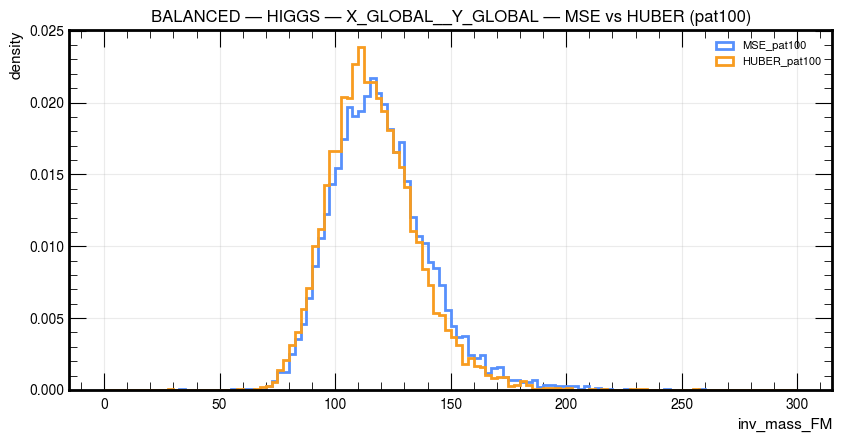

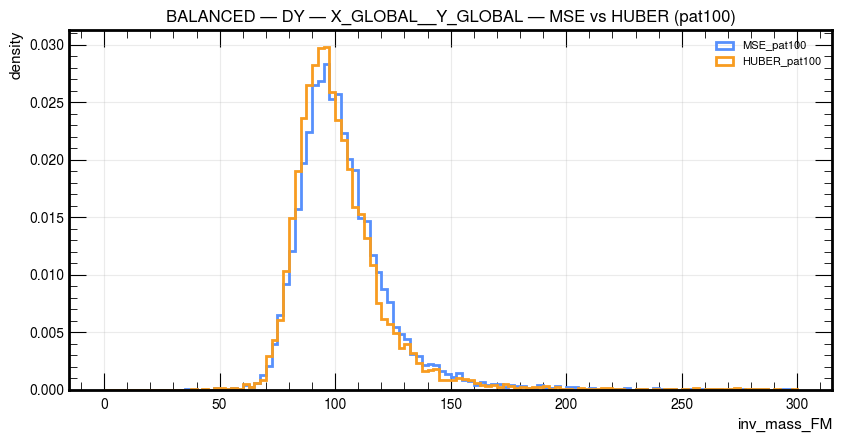

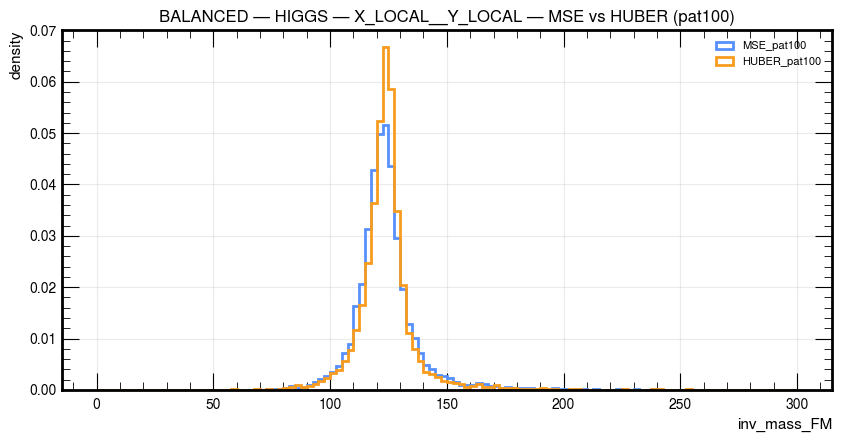

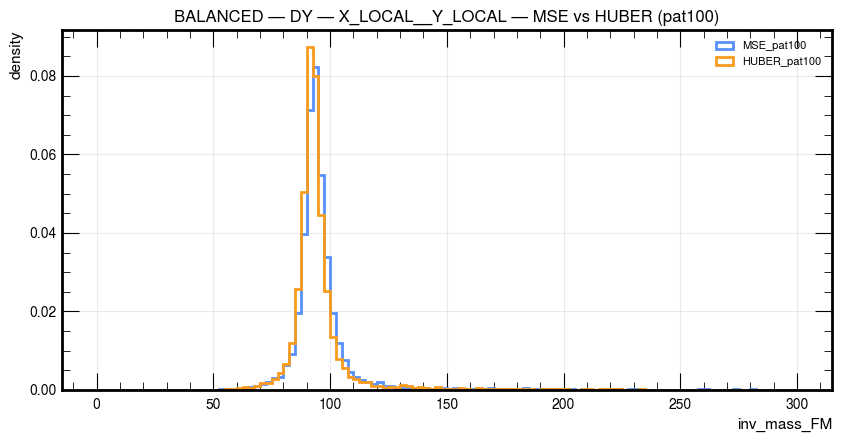

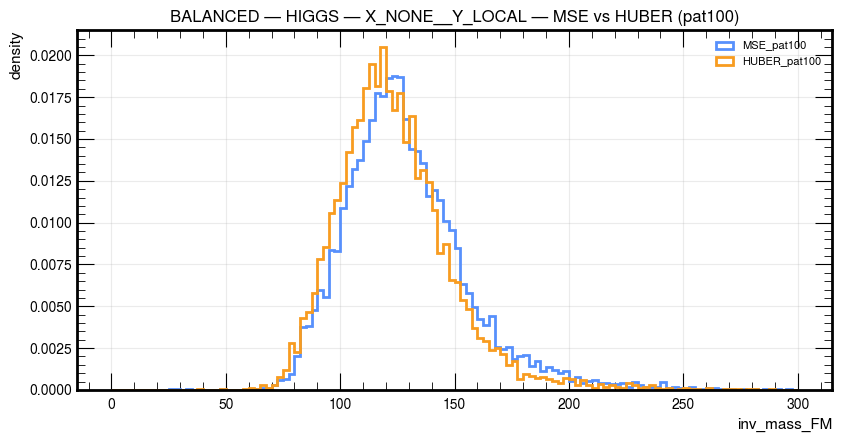

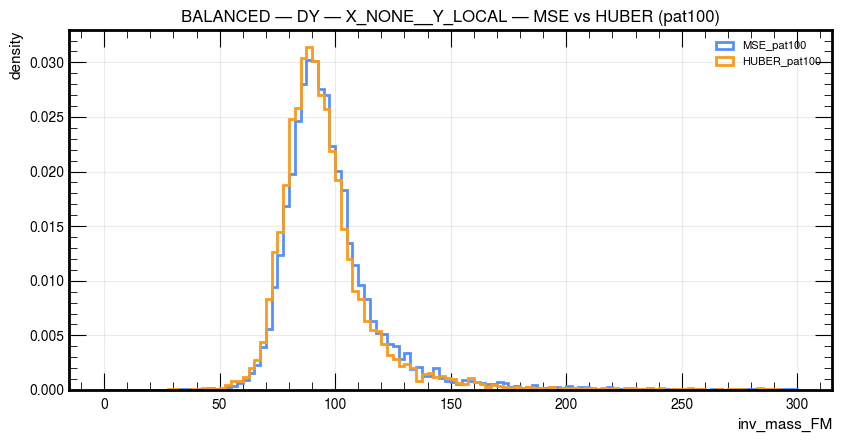

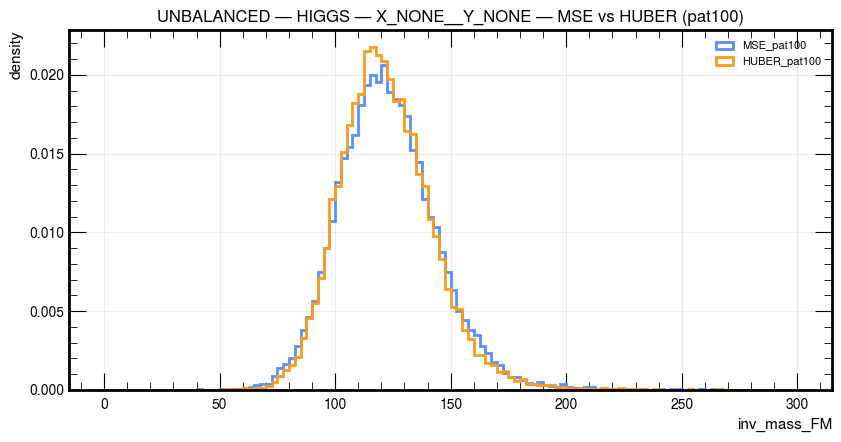

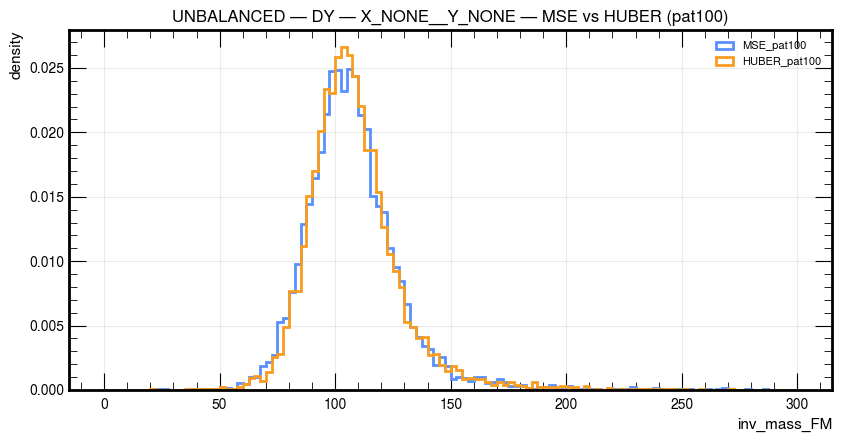

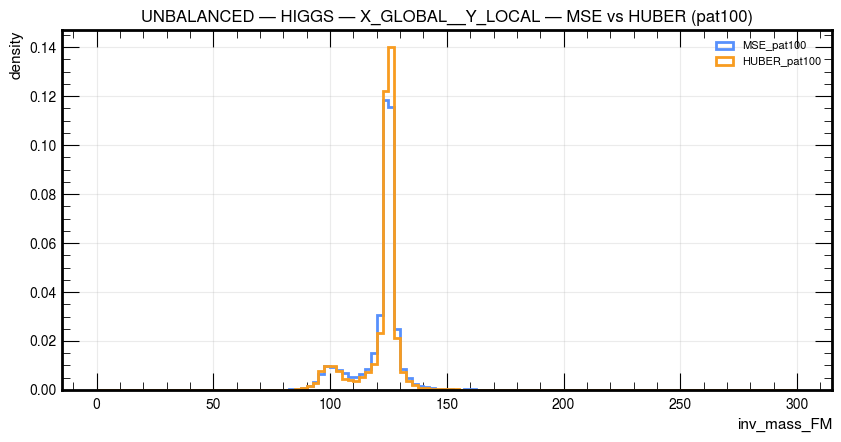

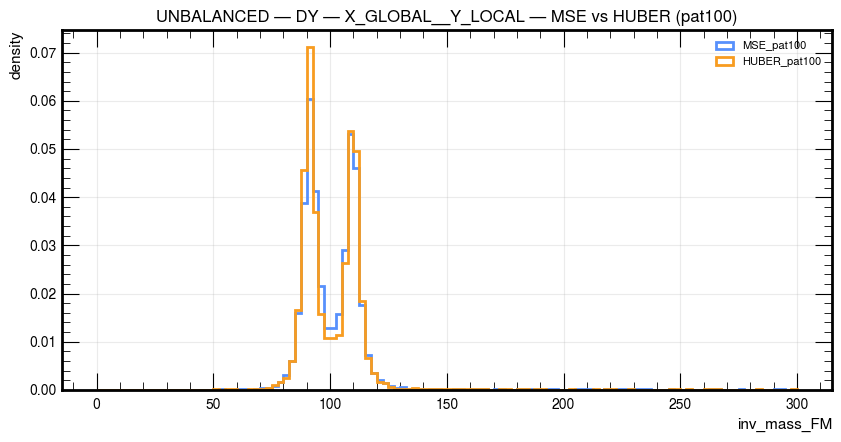

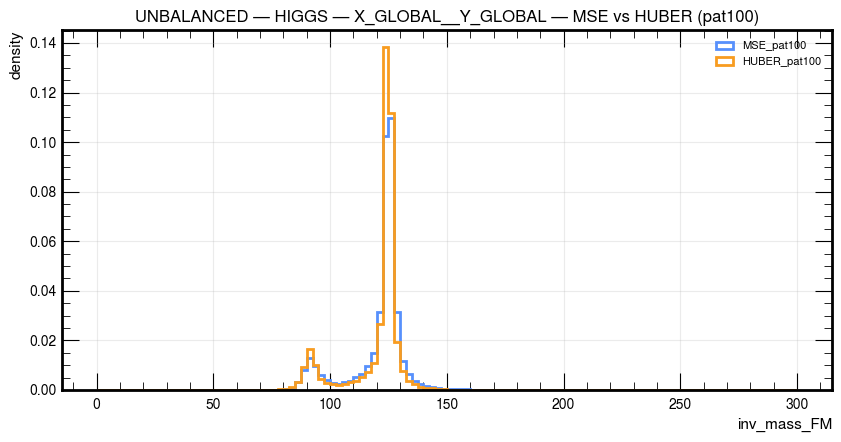

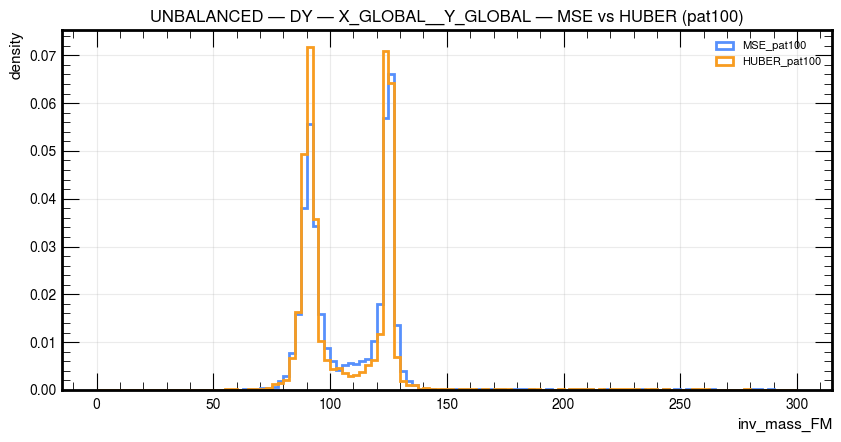

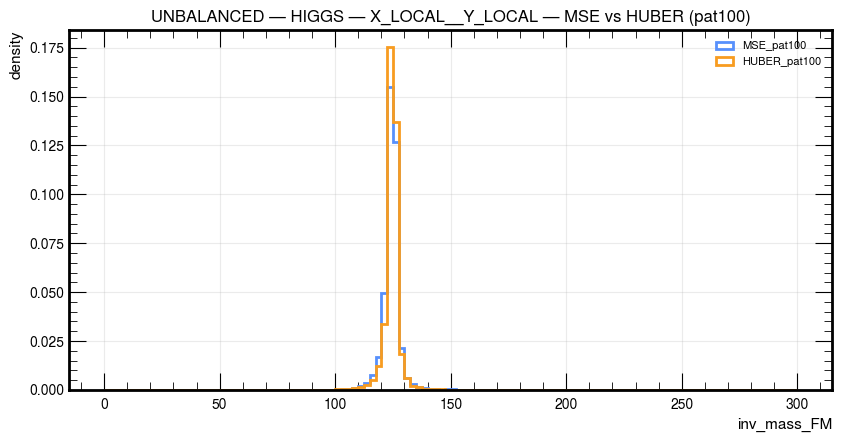

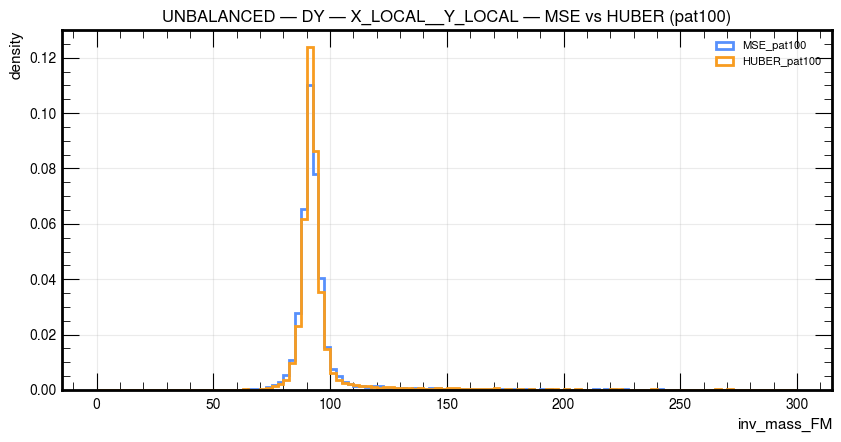

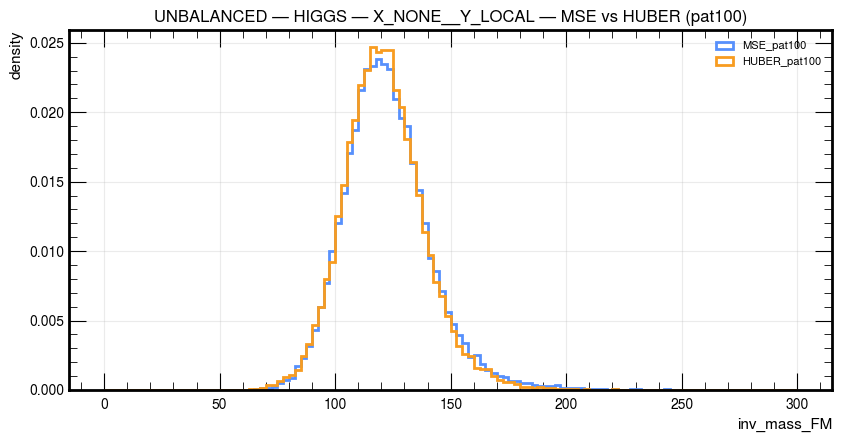

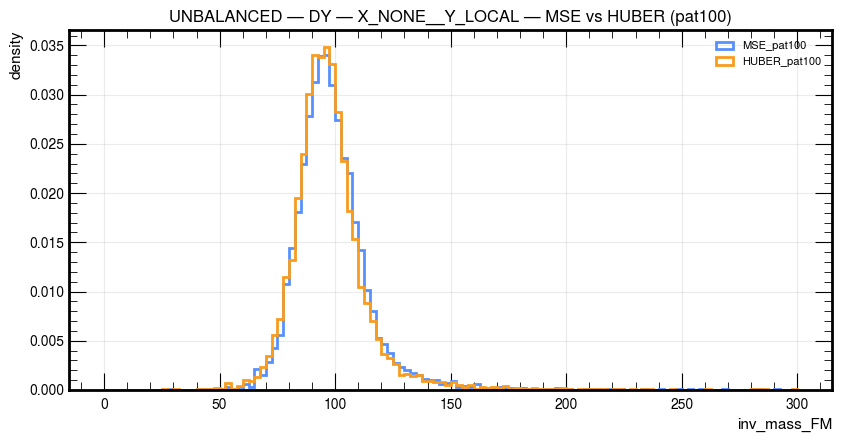

In [60]:
for mode in SCALING_MODES:

    massesPlots.plot_mass_overlay(
        {
            "MSE_pat100": masses_bal_h_mse_pat100[mode],
            "HUBER_pat100": masses_bal_h_huber_pat100[mode],
        },
        title=f"BALANCED — HIGGS — {mode} — MSE vs HUBER (pat100)",
        bins=120,
        range_=common_range,
        density=True,
    )

    massesPlots.plot_mass_overlay(
        {
            "MSE_pat100": masses_bal_dy_mse_pat100[mode],
            "HUBER_pat100": masses_bal_dy_huber_pat100[mode],
        },
        title=f"BALANCED — DY — {mode} — MSE vs HUBER (pat100)",
        bins=120,
        range_=common_range,
        density=True,
    )

for mode in SCALING_MODES:

    massesPlots.plot_mass_overlay(
        {
            "MSE_pat100": masses_unb_h_mse_pat100[mode],
            "HUBER_pat100": masses_unb_h_huber_pat100[mode],
        },
        title=f"UNBALANCED — HIGGS — {mode} — MSE vs HUBER (pat100)",
        bins=120,
        range_=common_range,
        density=True,
    )

    massesPlots.plot_mass_overlay(
        {
            "MSE_pat100": masses_unb_dy_mse_pat100[mode],
            "HUBER_pat100": masses_unb_dy_huber_pat100[mode],
        },
        title=f"UNBALANCED — DY — {mode} — MSE vs HUBER (pat100)",
        bins=120,
        range_=common_range,
        density=True,
    )

# Analysis

In [63]:
# =========================
# MSE 
# =========================
bal_mse_npz = np.load(os.path.join(OUT, "masses_bal_nonflat_mse_verified.npz"))
unbal_mse_npz = np.load(os.path.join(OUT, "masses_unbal_nonflat_mse_verified.npz"))

masses_bal_mse_pat100 = {mode: bal_mse_npz[mode] for mode in SCALING_MODES}
masses_unbal_mse_pat100 = {mode: unbal_mse_npz[mode] for mode in SCALING_MODES}

In [64]:
df_sob_mse_pat100, df_sob_pivot_mse_pat100 = analysis.compute_S_over_B_all_modes(
    masses_bal=masses_bal_mse_pat100,
    masses_unbal=masses_unbal_mse_pat100,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    window=(110, 130),
)

df_sob_huber_pat100, df_sob_pivot_huber_pat100 = analysis.compute_S_over_B_all_modes(
    masses_bal=masses_bal_huber_pat100,
    masses_unbal=masses_unbal_huber_pat100,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    window=(110, 130),
)

df_compare_pat100 = df_sob_pivot_mse_pat100.merge(
    df_sob_pivot_huber_pat100,
    on="mode",
    suffixes=("_MSE_pat100", "_HUBER_pat100"),
)

df_compare_pat100

,mode,balanced_MSE_pat100,unbalanced_MSE_pat100,balanced_HUBER_pat100,unbalanced_HUBER_pat100
0,X_GLOBAL__Y_GLOBAL,1.971893,5.288836,2.322230,5.818105
1,X_GLOBAL__Y_LOCAL,4.863694,12.687538,5.083333,12.555293
2,X_LOCAL__Y_LOCAL,20.907143,136.910112,27.215859,137.284916
3,X_NONE__Y_LOCAL,3.035332,10.823529,3.766367,13.458904
4,X_NONE__Y_NONE,1.575379,4.156370,1.739319,4.311710
